In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import cv2
import json
import matplotlib.pyplot as plt
from pathlib import Path
import sys
from typing import Any

from project_root import PROJECT_ROOT

import fiftyone as fo
import fiftyone.utils.torch as fout


import torchvision as tv

from scripts.model_serialization import load_model

In [2]:
ds_zoo_elephants = fo.load_dataset("zoo-elephants-sleep-val")
classes = sorted(ds_zoo_elephants.classes["ground_truth"])
print(classes)

['01_standing', '02_sleeping_left', '03_sleeping_right']


In [3]:
# model_path = PROJECT_ROOT / "models/identity/freeze09/dense121_c5_identity2.pth"
model_path = Path("/home/dherrera/temp/sleep/checkpoint.pth")
model = load_model(model_path)

config = fout.TorchImageModelConfig(
    {
        "entrypoint_fcn": lambda: model,
        "entrypoint_args": {},
        "output_processor": fout.ClassifierOutputProcessor(
            classes=classes, store_logits=True
        ),
        "classes": classes,
        # "transforms": torchvision.transforms.PILToTensor(),
        "image_min_dim": 224,
        "image_max_dim": 2048,
    }
)
fo_model = fout.TorchImageModel(config)

print("Applying model to samples...")
# ds_zoo_elephants.apply_model(fo_model, label_field="zoo_identity")
# predictions_view = ds_zoo_elephants.take(100, seed=51)
predictions_view = ds_zoo_elephants
predictions_view.apply_model(fo_model, label_field="prediction")
# high_conf_view = predictions_view.filter_labels("zoo maskrcnn", fo.ViewField("confidence") > 0.85, only_matches=False)

# session.view = predictions_view

Loading weights from disk...
Loading empty model...
Restoring weights...
Applying model to samples...
  36% |██████\----------|  38/107 [733.8ms elapsed, 1.3s remaining, 51.8 samples/s] 

/home/dherrera/git/zoo_vision/env/lib/python3.11/site-packages/fiftyone/utils/torch.py:1111: RuntimeWarning: overflow encountered in exp
  odds = np.exp(logits)
/home/dherrera/git/zoo_vision/env/lib/python3.11/site-packages/fiftyone/utils/torch.py:1112: RuntimeWarning: invalid value encountered in divide
  odds /= np.sum(odds, axis=1, keepdims=True)


 100% |█████████████████| 107/107 [1.4s elapsed, 0s remaining, 108.9 samples/s]        


In [4]:
results = ds_zoo_elephants.evaluate_classifications(
    pred_field="prediction",
    gt_field="ground_truth",
    eval_key="eval",
    method="simple",
    classes=classes,
)

In [5]:
gt_counts = dict(sorted(predictions_view.count_values("ground_truth.label").items()))
pd_counts = dict(sorted(predictions_view.count_values("prediction.label").items()))
print(gt_counts)
print(pd_counts)
# ds_zoo_elephants.iter_samples().__next__().get_field("ground_truth").get_field("label")

{'01_standing': 38, '02_sleeping_left': 35, '03_sleeping_right': 34}
{'01_standing': 33, '02_sleeping_left': 25, '03_sleeping_right': 49}


In [6]:
results.print_report()

                   precision    recall  f1-score   support

      01_standing       1.00      0.87      0.93        38
 02_sleeping_left       0.96      0.69      0.80        35
03_sleeping_right       0.69      1.00      0.82        34

         accuracy                           0.85       107
        macro avg       0.88      0.85      0.85       107
     weighted avg       0.89      0.85      0.85       107



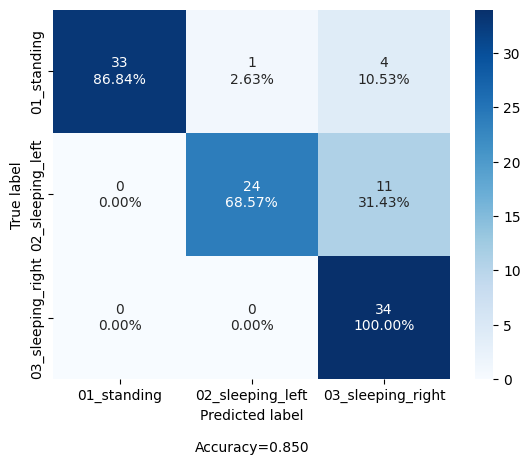

In [7]:
import seaborn as sns
from scripts.cf_matrix import make_confusion_matrix

m = results.confusion_matrix()
# sns.heatmap(m, annot=True,xticklabels=classes, yticklabels=classes, fmt="d")
make_confusion_matrix(m, categories=classes)

In [8]:
session = fo.launch_app(ds_zoo_elephants, auto=False)
session.open_tab()

Session launched. Run `session.show()` to open the App in a cell output.


<IPython.core.display.Javascript object>

In [ ]:
from fiftyone import ViewField as F

session.view = (
    ds_zoo_elephants
    # .match_tags("validation")
    .match(F("prediction.label") != F("ground_truth.label"))
    # .sort_by("uniqueness", reverse=True)
)